# Evaluate Model Predictions Against the New Annotation

Step by step:

1. Load the annotation conversion rule (Rules 1 + 3 from `annotation_conversion_test.ipynb`).
2. Discover every available model/parser combination (tag) with labeled output.
3. Apply the rule to each tag's predicted structured JSON -> save as **final JSON**.
4. Load gold pairs from the new-version ground truth.
5. Evaluate each tag's final JSON against the new-version gold.
6. Report F1 per label + confusion matrix, per tag.
7. Summary comparison across all tags.

This notebook is exploratory only — nothing here is wired into the package/pipeline. It reuses the matching/scoring engine from `dmpbridge.evaluation.evaluate` (already tested), and only adds the annotation-conversion step on top.

## Step 1 — The annotation conversion rule

Same rule as `annotation_conversion_test.ipynb`, validated there against the real new-version ground truth (exact match on 4 samples, content-match on 4 more; 2 known, characterized exceptions — see that notebook).

In [1]:
import copy
import json
import re
import tempfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from dmpbridge.evaluation.evaluate import (
    LABELS, LLM_DIR, NEW_MANUAL_DIR,
    _confusion_from_match, _match_structured,
    compute_f1_rows, confusion_matrix_df, extract_gold,
    list_tags, micro_prf1,
)

In [2]:
def apply_new_annotation_rules(data: dict) -> dict:
    """Return a copy of *data* with the empty-question backfill rule applied.

    Rule 1: a question with empty text is filled with its own section's title.
    Rule 3: if the section title is also empty, the document title fills the
    question instead (first occurrence only), then the document title is cleared.
    """
    data     = copy.deepcopy(data)
    root     = data.get('narrative', data)
    template = root.get('template', {})
    doc_title  = template.get('title', '').strip()
    title_used = False

    for section in template.get('section', []):
        sec_title = section.get('title', '').strip()
        for question in section.get('question', []):
            if question.get('text', '').strip():
                continue
            if sec_title:
                question['text'] = sec_title
            elif doc_title and not title_used:
                question['text'] = doc_title
                title_used = True

    if title_used:
        template['title'] = ''

    return data

## Step 2 — Discover available model/parser tags

Scans `data/output/labeled/` for every tag (model + PDF parser combination) that has structured JSON output — no hardcoded model or parser names, so this picks up new ones automatically.

In [3]:
TAGS = list_tags()
for tag in TAGS:
    n_files = len(list((LLM_DIR / tag).glob('*_structured.json')))
    print(f'{tag:<40} {n_files} structured file(s)')

gemma4-e4b_pdfplumber_whole_doc          10 structured file(s)
llama3.1-8b_pdfplumber_whole_doc         10 structured file(s)
llama3.3-70b_pdfplumber_whole_doc        10 structured file(s)


## Step 3 — Apply the rule to every tag's predictions -> save as final JSON

Writes to `data/output/labeled_final/<tag>/sampleN_structured.json`, mirroring the existing `data/output/labeled/<tag>/` layout.

In [4]:
FINAL_DIR = LLM_DIR.parent / 'labeled_final'

for tag in TAGS:
    src_dir = LLM_DIR / tag
    dst_dir = FINAL_DIR / tag
    dst_dir.mkdir(parents=True, exist_ok=True)
    n_written = n_changed = 0
    for src in sorted(src_dir.glob('*_structured.json')):
        pred  = json.loads(src.read_text(encoding='utf-8'))
        final = apply_new_annotation_rules(pred)
        (dst_dir / src.name).write_text(json.dumps(final, indent=2, ensure_ascii=False), encoding='utf-8')
        n_written += 1
        n_changed += (pred != final)
    print(f'{tag:<40} {n_changed}/{n_written} file(s) changed  ->  {dst_dir}')

gemma4-e4b_pdfplumber_whole_doc          9/10 file(s) changed  ->  C:\Users\Nahid\dmpbridge\data\output\labeled_final\gemma4-e4b_pdfplumber_whole_doc
llama3.1-8b_pdfplumber_whole_doc         10/10 file(s) changed  ->  C:\Users\Nahid\dmpbridge\data\output\labeled_final\llama3.1-8b_pdfplumber_whole_doc
llama3.3-70b_pdfplumber_whole_doc        10/10 file(s) changed  ->  C:\Users\Nahid\dmpbridge\data\output\labeled_final\llama3.3-70b_pdfplumber_whole_doc


## Step 4 — Load gold pairs from the new-version ground truth

New-version filenames don't follow one consistent pattern (see `annotation_conversion_test.ipynb`), so this resolves by sample number instead of a hardcoded name.

In [5]:
def new_gt_path(n: int) -> Path:
    for p in NEW_MANUAL_DIR.glob('*.json'):
        m = re.fullmatch(r'\D*(\d+)\D*', p.stem)
        if m and int(m.group(1)) == n:
            return p
    raise FileNotFoundError(f'No new-version ground truth file found for sample{n}')


NEW_GOLD = {n: extract_gold(new_gt_path(n)) for n in range(1, 11)}
for n, pairs in NEW_GOLD.items():
    print(f'sample{n:<2}  {len(pairs)} gold item(s)')

sample1   28 gold item(s)
sample2   25 gold item(s)
sample3   14 gold item(s)
sample4   2 gold item(s)
sample5   13 gold item(s)
sample6   11 gold item(s)
sample7   2 gold item(s)
sample8   13 gold item(s)
sample9   11 gold item(s)
sample10  13 gold item(s)


## Step 5 — Evaluate each tag's final JSON against the new-version gold

Reuses the same greedy matcher (`_match_structured`) and confusion-matrix builder (`_confusion_from_match`) from `dmpbridge.evaluation.evaluate` — the same code path already used and tested for the old-annotation evaluation, just pointed at the new gold and the rule-converted ("final") predictions instead.

In [6]:
results = {}

for tag in TAGS:
    total_confusion = defaultdict(lambda: defaultdict(int))
    for n in range(1, 11):
        final_path = FINAL_DIR / tag / f'sample{n}_structured.json'
        if not final_path.exists():
            continue
        records, no_gold = _match_structured(final_path, NEW_GOLD[n])
        conf = _confusion_from_match(records, no_gold)
        for true_lbl, preds in conf.items():
            for pred_lbl, count in preds.items():
                total_confusion[true_lbl][pred_lbl] += count
    results[tag] = total_confusion

print('Evaluated tags:', list(results.keys()))

Evaluated tags: ['gemma4-e4b_pdfplumber_whole_doc', 'llama3.1-8b_pdfplumber_whole_doc', 'llama3.3-70b_pdfplumber_whole_doc']


## Step 6 — F1 per label + confusion matrix, per tag

  gemma4-e4b_pdfplumber_whole_doc

Label                    Precision    Recall        F1   Support
--------------------------------------------------------------
title                       100.0%     87.5%     93.3%         8
section.title                69.2%     83.7%     75.8%        43
section.description          46.7%     87.5%     60.9%         8
question.text                40.7%     61.1%     48.9%        18
answer.text                  77.8%     76.4%     77.1%        55

Overall (micro)  Precision  66.5%  Recall  78.0%  F1  71.8%  (TP=103  FP=52  FN=29)


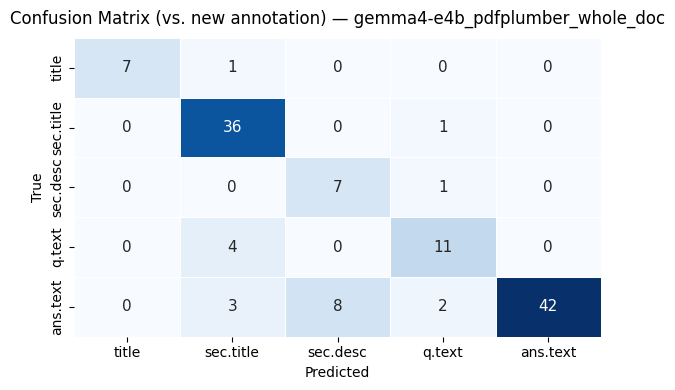


  llama3.1-8b_pdfplumber_whole_doc

Label                    Precision    Recall        F1   Support
--------------------------------------------------------------
title                       100.0%    100.0%    100.0%         8
section.title                64.9%     86.0%     74.0%        43
section.description          66.7%     25.0%     36.4%         8
question.text                10.5%     55.6%     17.7%        18
answer.text                  37.7%     83.6%     52.0%        55

Overall (micro)  Precision  36.1%  Recall  78.0%  F1  49.4%  (TP=103  FP=182  FN=29)


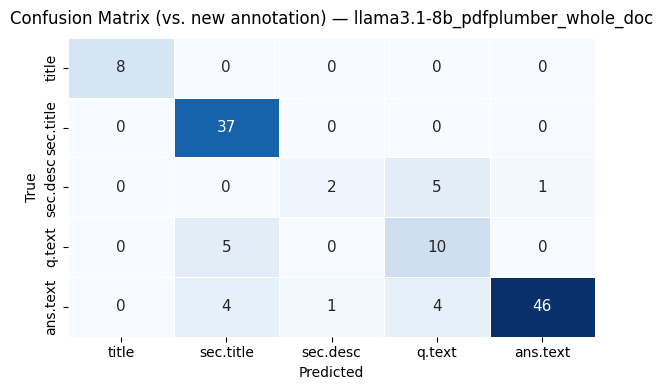


  llama3.3-70b_pdfplumber_whole_doc

Label                    Precision    Recall        F1   Support
--------------------------------------------------------------
title                       100.0%    100.0%    100.0%         8
section.title                67.9%     88.4%     76.8%        43
section.description          44.4%    100.0%     61.5%         8
question.text                64.7%     61.1%     62.9%        18
answer.text                  70.3%     81.8%     75.6%        55

Overall (micro)  Precision  67.5%  Recall  83.3%  F1  74.6%  (TP=110  FP=53  FN=22)


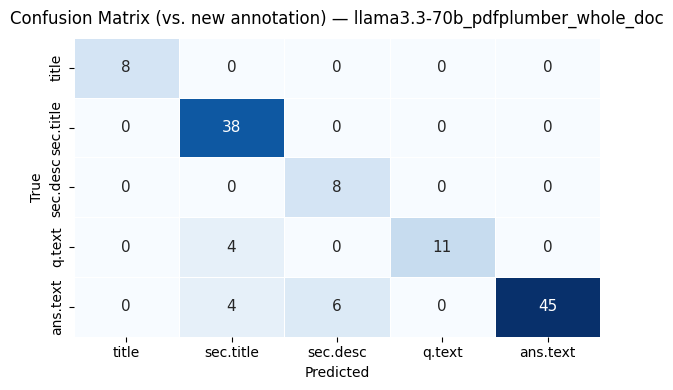

In [7]:
for tag, conf in results.items():
    print('=' * 70)
    print(f'  {tag}')
    print('=' * 70)

    df_f1 = compute_f1_rows(conf)
    print(f"\n{'Label':<22}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'Support':>8}")
    print('-' * 62)
    for row in df_f1.itertuples():
        print(f'{row.label:<22}  {row.precision*100:>9.1f}%  {row.recall*100:>7.1f}%  {row.f1*100:>7.1f}%  {row.support:>8}')

    m = micro_prf1(conf)
    print(f"\nOverall (micro)  Precision {m['precision']*100:5.1f}%  "
          f"Recall {m['recall']*100:5.1f}%  F1 {m['f1']*100:5.1f}%  "
          f"(TP={m['tp']}  FP={m['fp']}  FN={m['fn']})")

    mat = confusion_matrix_df(conf).drop(columns=['missed'])
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
                linecolor='white', ax=ax, cbar=False, annot_kws={'size': 11})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix (vs. new annotation) \u2014 {tag}', pad=10)
    plt.tight_layout()
    plt.show()
    print()

## Step 7 — Summary comparison across all tags

Tag                                        Precision    Recall        F1
------------------------------------------------------------------------
gemma4-e4b_pdfplumber_whole_doc                66.5%     78.0%     71.8%
llama3.1-8b_pdfplumber_whole_doc               36.1%     78.0%     49.4%
llama3.3-70b_pdfplumber_whole_doc              67.5%     83.3%     74.6%


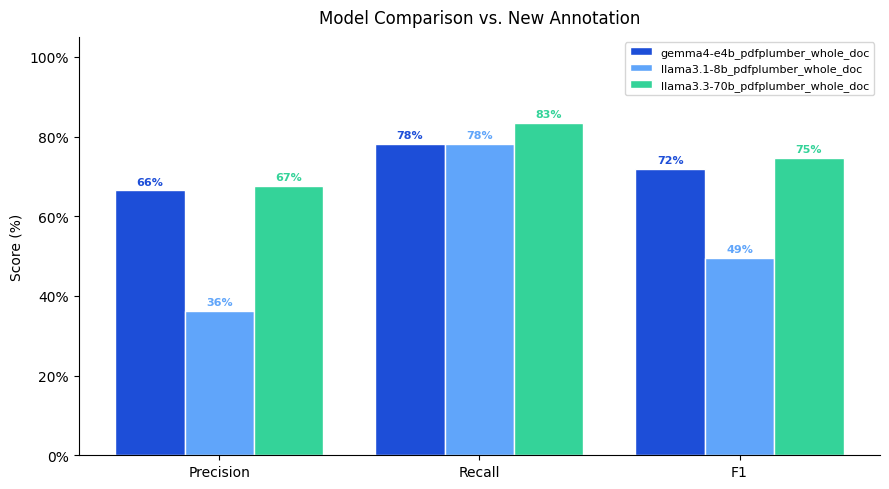

In [8]:
summary_rows = []
for tag, conf in results.items():
    m = micro_prf1(conf)
    summary_rows.append({'tag': tag, **m})

summary_df = pd.DataFrame(summary_rows).set_index('tag')
print(f"{'Tag':<40}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
print('-' * 72)
for tag, row in summary_df.iterrows():
    print(f"{tag:<40}  {row['precision']*100:>9.1f}%  {row['recall']*100:>7.1f}%  {row['f1']*100:>7.1f}%")

COLORS = ['#1d4ed8', '#60a5fa', '#34d399', '#f59e0b']
metrics = ['precision', 'recall', 'f1']
metric_labels = ['Precision', 'Recall', 'F1']
n_tags = len(summary_df)
w = 0.8 / n_tags
xi = range(len(metrics))

fig, ax = plt.subplots(figsize=(9, 5))
for i, (tag, color) in enumerate(zip(summary_df.index, COLORS[:n_tags])):
    offset = (i - n_tags / 2 + 0.5) * w
    vals = [summary_df.loc[tag, m] * 100 for m in metrics]
    bars = ax.bar([x + offset for x in xi], vals, width=w, label=tag, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.0f}%',
                ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 105)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison vs. New Annotation', pad=10)
ax.legend(loc='upper right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()